In [1]:
import numpy as np
import matplotlib as plt
from src.bernouilli_bandit import BernoulliBandit
from src.thompson_sampling import ThompsonSampling
from src.epsilon_greedy import EpsilonGreedy
from src.upper_confidence_bound import UCB1
import matplotlib.pyplot as plt

#### Setting up the main functions

In [2]:
def run_experiment(bandit, algo, steps):
    rewards = np.zeros(steps)
    optimal = np.zeros(steps)

    best_arm = np.argmax(bandit.probs)

    for t in range(steps):
        arm = algo.select_arm()
        reward = bandit.pull(arm)
        algo.update(arm, reward)

        rewards[t] = reward
        optimal[t] = (arm == best_arm)

    return rewards, optimal

In [3]:
def compare_algorithms(bandit, algorithms, steps=5000):
    results = {}

    for name, algo in algorithms.items():
        rewards, optimal = run_experiment(bandit, algo, steps)
        results[name] = {
            "rewards": rewards,
            "cumulative": rewards.cumsum(),
            "optimal_rate": optimal.cumsum() / (np.arange(1, steps+1))
        }
    
    return results

In [4]:
def plot_cumulative_reward(results):
    plt.figure(figsize=(8,5))
    for name, data in results.items():
        plt.plot(data["cumulative"], label=name)
    plt.xlabel("Steps")
    plt.ylabel("Cumulative Reward")
    plt.title("Cumulative Reward Comparison")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_optimal_rate(results):
    plt.figure(figsize=(8,5))
    for name, data in results.items():
        plt.plot(data["optimal_rate"], label=name)
    plt.xlabel("Steps")
    plt.ylabel("Optimal Arm Pull Rate")
    plt.title("Optimal Arm Selection Rate Over Time")
    plt.grid(True)
    plt.legend()
    plt.show()

#### Running the whole thing

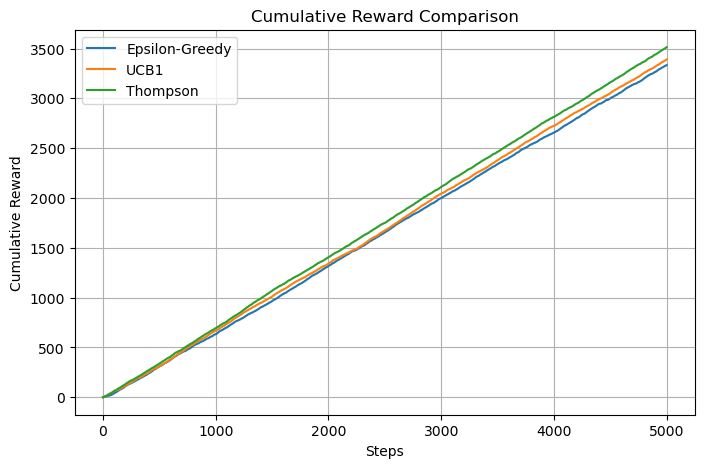

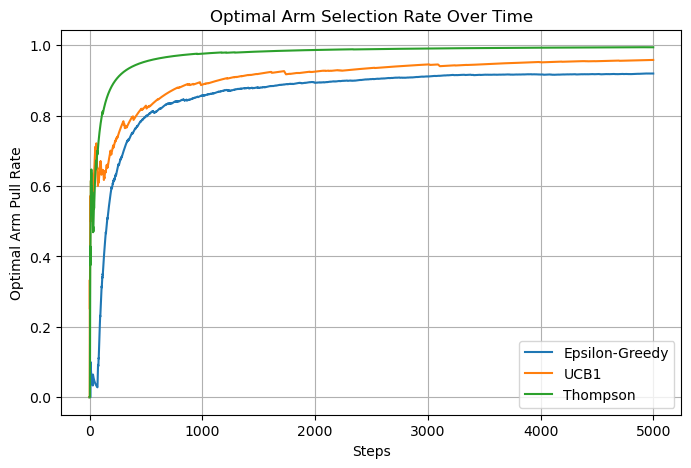

In [5]:
bandit = BernoulliBandit([0.2, 0.5, 0.7])

algos = {
    "Epsilon-Greedy": EpsilonGreedy(k=3, epsilon=0.1),
    "UCB1": UCB1(k=3),
    "Thompson": ThompsonSampling(k=3)
}

results = compare_algorithms(bandit, algos, steps=5000)

plot_cumulative_reward(results)
plot_optimal_rate(results)
